# 🚦 Traffic Sign Classifier — Notebook 1: Huấn luyện mô hình

---

**Mục tiêu:** Xây dựng và huấn luyện CNN (Convolutional Neural Network) nhận diện **43 loại biển báo giao thông** từ bộ dữ liệu GTSRB.

**Pipeline tổng quan:**
```
📂 Dataset  →  🔄 Tiền xử lý  →  📊 Augmentation  →  🧠 Huấn luyện CNN  →  💾 Lưu model
```

| Thông số | Giá trị |
|---|---|
| Số lớp biển báo | 43 |
| Kích thước ảnh đầu vào | 30 × 30 × 3 |
| Framework | TensorFlow / Keras |
| Optimizer | Adam |
| Loss | Categorical Crossentropy |

## 📦 Bước 0 — Cài đặt thư viện

Chạy cell này nếu chưa cài đặt các thư viện cần thiết.

In [1]:
# Cài đặt thư viện (bỏ comment nếu cần)
# !pip install tensorflow pillow scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import tensorflow as tf
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ NumPy version:      {np.__version__}")
print(f"✅ GPU available:      {len(tf.config.list_physical_devices('GPU')) > 0}")

c:\Users\Lactv\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


✅ TensorFlow version: 2.21.0
✅ NumPy version:      1.26.4
✅ GPU available:      False


## 📂 Bước 1 — Load dữ liệu

Dữ liệu được tổ chức theo cấu trúc:
```
Train/
├── 0/   ← Biển báo class 0 (Giới hạn tốc độ 20 km/h)
├── 1/   ← Biển báo class 1 (Giới hạn tốc độ 30 km/h)
├── ...
└── 42/  ← Biển báo class 42
```

Mỗi ảnh được:
- Resize về **30×30 pixels**
- Normalize về khoảng **[0, 1]** (chia 255)

In [2]:
data = []
labels = []
classes = 43
cur_path = os.getcwd()

print("⏳ Đang load dữ liệu...")

class_counts = {}  # Để visualize sau

for i in range(classes):
    path = os.path.join(cur_path, 'Train', str(i))
    if not os.path.exists(path):
        print(f"  ⚠️  Không tìm thấy thư mục: {path}")
        continue
    images = os.listdir(path)
    class_counts[i] = 0

    for img_name in images:
        try:
            img = Image.open(os.path.join(path, img_name)).convert("RGB")
            img = img.resize((30, 30))
            img = np.array(img)
            data.append(img)
            labels.append(i)
            class_counts[i] += 1
        except Exception as e:
            pass  # Bỏ qua ảnh lỗi

# Normalize
data = np.array(data) / 255.0
labels = np.array(labels)

# Shuffle
data, labels = shuffle(data, labels, random_state=42)

print(f"✅ Tổng số ảnh load được : {data.shape[0]:,}")
print(f"✅ Shape của data        : {data.shape}")
print(f"✅ Số lớp biển báo       : {len(class_counts)}")

⏳ Đang load dữ liệu...
✅ Tổng số ảnh load được : 39,209
✅ Shape của data        : (39209, 30, 30, 3)
✅ Số lớp biển báo       : 43


### 📊 Visualize phân phối dữ liệu theo class

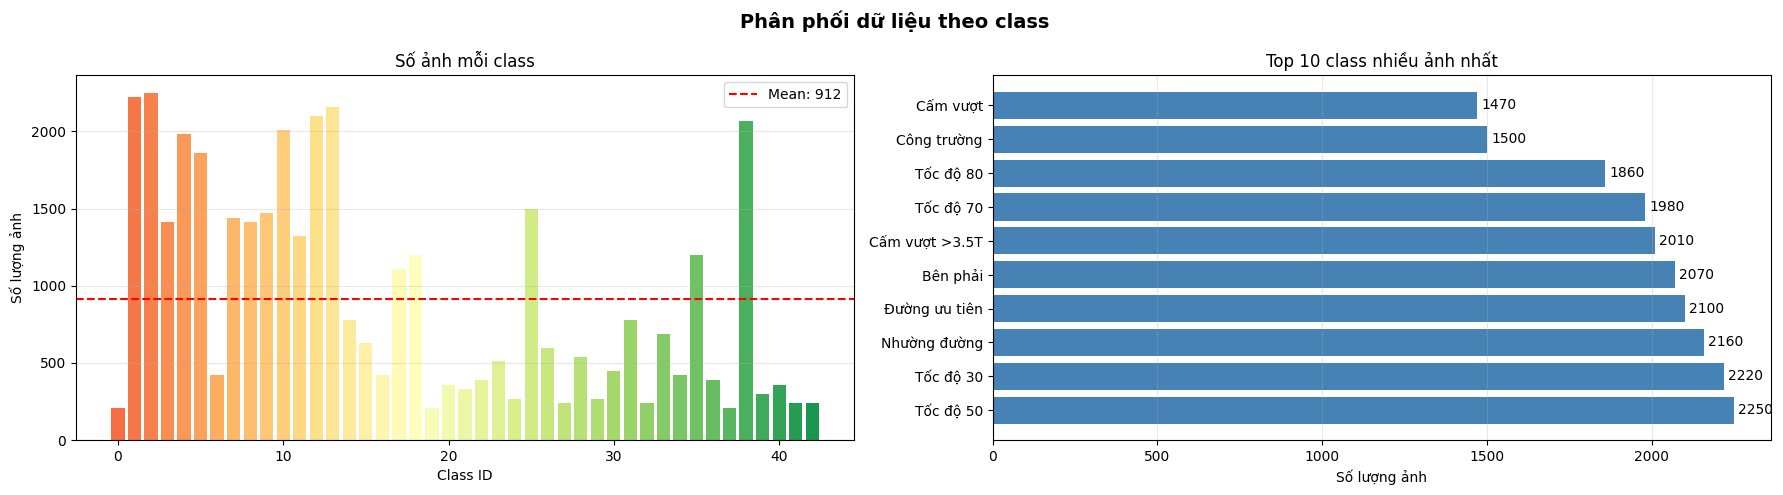

💾 Đã lưu biểu đồ: data_distribution.png


In [3]:
label_names = {
    0: "Tốc độ 20", 1: "Tốc độ 30", 2: "Tốc độ 50", 3: "Tốc độ 60",
    4: "Tốc độ 70", 5: "Tốc độ 80", 6: "Hết 80", 7: "Tốc độ 100",
    8: "Tốc độ 120", 9: "Cấm vượt", 10: "Cấm vượt >3.5T", 11: "Ưu tiên ngã tư",
    12: "Đường ưu tiên", 13: "Nhường đường", 14: "STOP", 15: "Cấm xe",
    16: "Cấm xe >3.5T", 17: "Cấm vào", 18: "Nguy hiểm", 19: "Cua trái",
    20: "Cua phải", 21: "Đường cong", 22: "Gồ ghề", 23: "Trơn trượt",
    24: "Đường hẹp", 25: "Công trường", 26: "Đèn giao thông", 27: "Người đi bộ",
    28: "Trẻ em", 29: "Xe đạp", 30: "Băng/tuyết", 31: "Động vật",
    32: "Hết giới hạn", 33: "Rẽ phải", 34: "Rẽ trái", 35: "Đi thẳng",
    36: "Thẳng/phải", 37: "Thẳng/trái", 38: "Bên phải", 39: "Bên trái",
    40: "Vòng xuyến", 41: "Hết cấm vượt", 42: "Hết cấm >3.5T"
}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Phân phối dữ liệu theo class', fontsize=14, fontweight='bold')

# Biểu đồ cột
ax1 = axes[0]
counts = [class_counts.get(i, 0) for i in range(classes)]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, classes))
bars = ax1.bar(range(classes), counts, color=colors, edgecolor='none')
ax1.set_xlabel('Class ID')
ax1.set_ylabel('Số lượng ảnh')
ax1.set_title('Số ảnh mỗi class')
ax1.axhline(y=np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.0f}')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Top 10 class nhiều ảnh nhất
ax2 = axes[1]
top10 = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)[:10]
top_labels = [f"{label_names.get(k, f'Class {k}')}" for k, v in top10]
top_values = [v for k, v in top10]
bars2 = ax2.barh(top_labels, top_values, color='steelblue')
ax2.set_xlabel('Số lượng ảnh')
ax2.set_title('Top 10 class nhiều ảnh nhất')
ax2.bar_label(bars2, padding=3)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Đã lưu biểu đồ: data_distribution.png")

### 🖼️ Visualize mẫu ảnh từ mỗi class

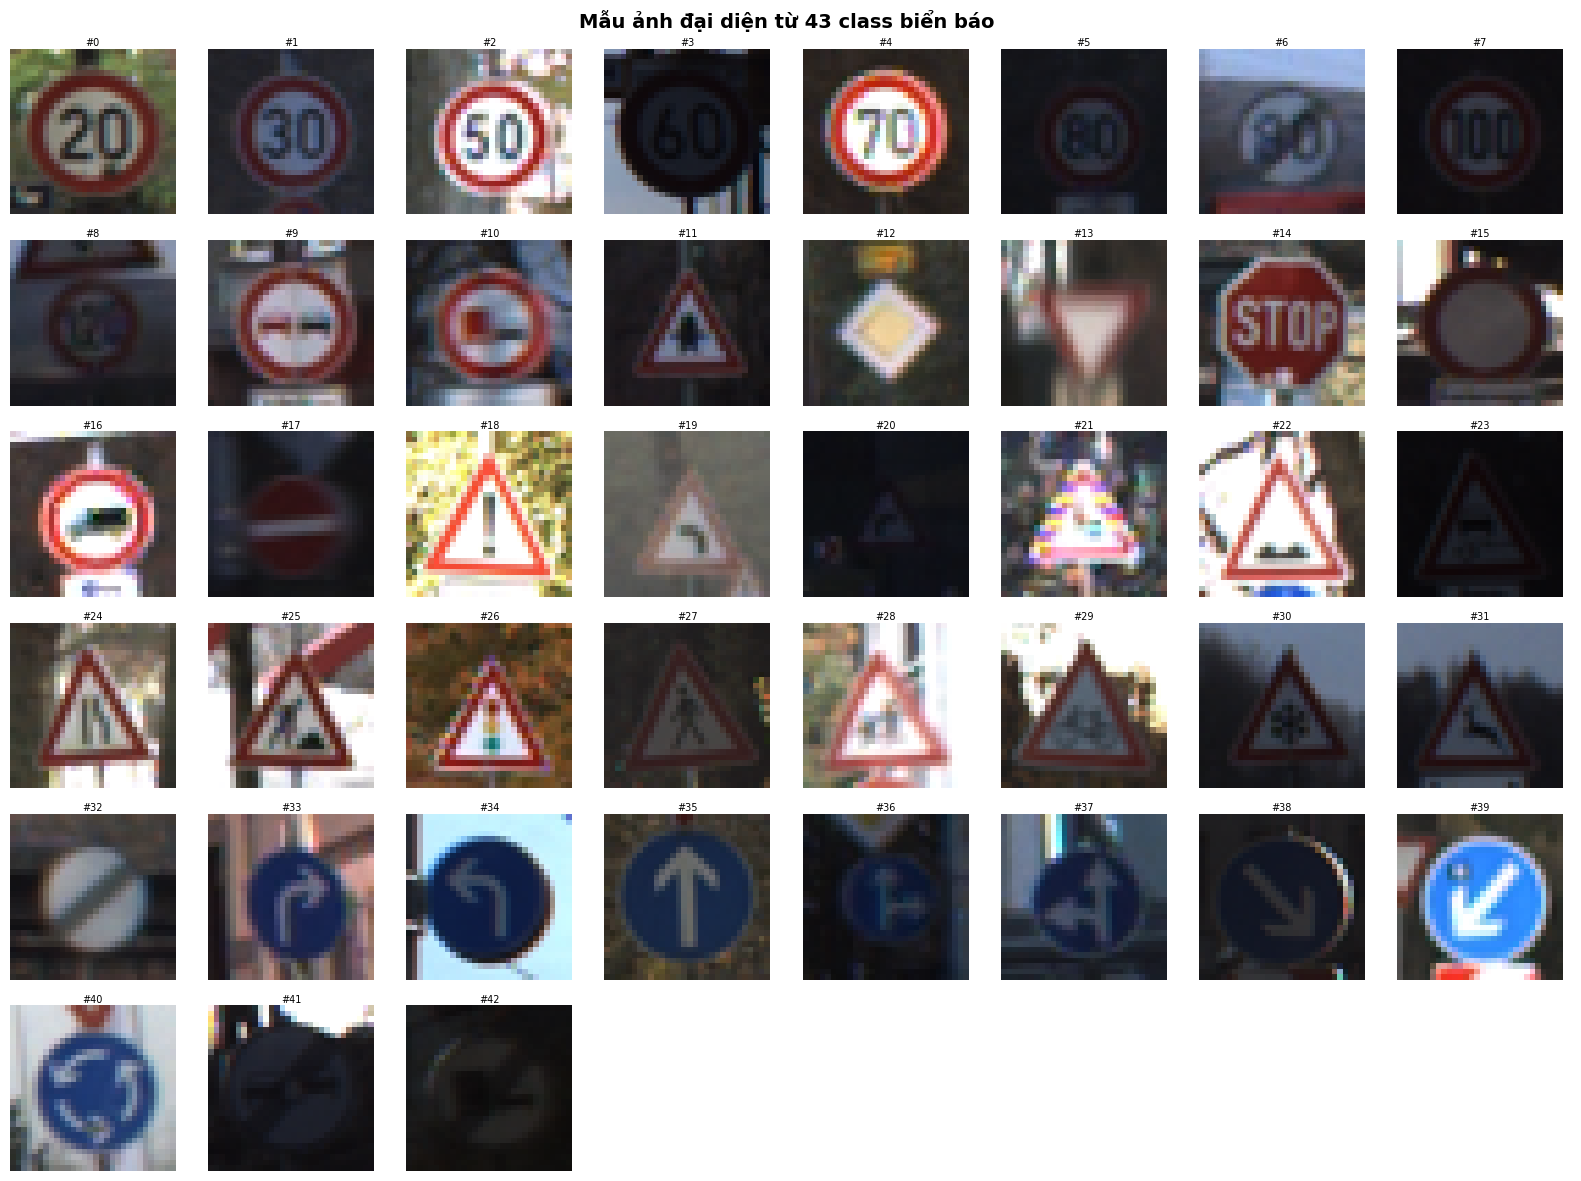

💾 Đã lưu: sample_images.png


In [4]:
fig, axes = plt.subplots(6, 8, figsize=(16, 12))
fig.suptitle('Mẫu ảnh đại diện từ 43 class biển báo', fontsize=14, fontweight='bold')

for class_id in range(43):
    ax = axes[class_id // 8][class_id % 8]
    # Tìm ảnh đầu tiên của class này
    idx = np.where(labels == class_id)[0]
    if len(idx) > 0:
        ax.imshow(data[idx[0]])
    ax.set_title(f'#{class_id}', fontsize=7, pad=2)
    ax.axis('off')

# Tắt các ô thừa (43 class, grid 6×8 = 48 ô)
for i in range(43, 48):
    axes[i // 8][i % 8].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: sample_images.png")

## ✂️ Bước 2 — Chia tập Train / Test

Tỷ lệ: **80% Train** / **20% Test**

Nhãn được chuyển sang dạng **one-hot encoding** (ví dụ: class 3 → `[0,0,0,1,0,...,0]`)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

y_train_cat = to_categorical(y_train, classes)
y_test_cat  = to_categorical(y_test,  classes)

print(f"📊 Tập Train  : {X_train.shape[0]:,} ảnh  →  X_train: {X_train.shape}")
print(f"📊 Tập Test   : {X_test.shape[0]:,}  ảnh  →  X_test:  {X_test.shape}")
print(f"📊 y_train (one-hot): {y_train_cat.shape}")
print(f"📊 y_test  (one-hot): {y_test_cat.shape}")

📊 Tập Train  : 31,367 ảnh  →  X_train: (31367, 30, 30, 3)
📊 Tập Test   : 7,842  ảnh  →  X_test:  (7842, 30, 30, 3)
📊 y_train (one-hot): (31367, 43)
📊 y_test  (one-hot): (7842, 43)


## 🔄 Bước 3 — Data Augmentation

Tăng cường dữ liệu để model tổng quát hóa tốt hơn, tránh overfitting:

| Kỹ thuật | Giá trị |
|---|---|
| Xoay ảnh ngẫu nhiên | ±15° |
| Zoom ngẫu nhiên | ±20% |
| Dịch ngang | ±10% |
| Dịch dọc | ±10% |

In [6]:
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train)

print("✅ ImageDataGenerator đã khởi tạo với các tham số:")
print(f"   rotation_range    = 15°")
print(f"   zoom_range        = 0.2  (±20%)")
print(f"   width_shift_range = 0.1  (±10%)")
print(f"   height_shift_range= 0.1  (±10%)")

✅ ImageDataGenerator đã khởi tạo với các tham số:
   rotation_range    = 15°
   zoom_range        = 0.2  (±20%)
   width_shift_range = 0.1  (±10%)
   height_shift_range= 0.1  (±10%)


### 🖼️ Visualize ảnh sau augmentation

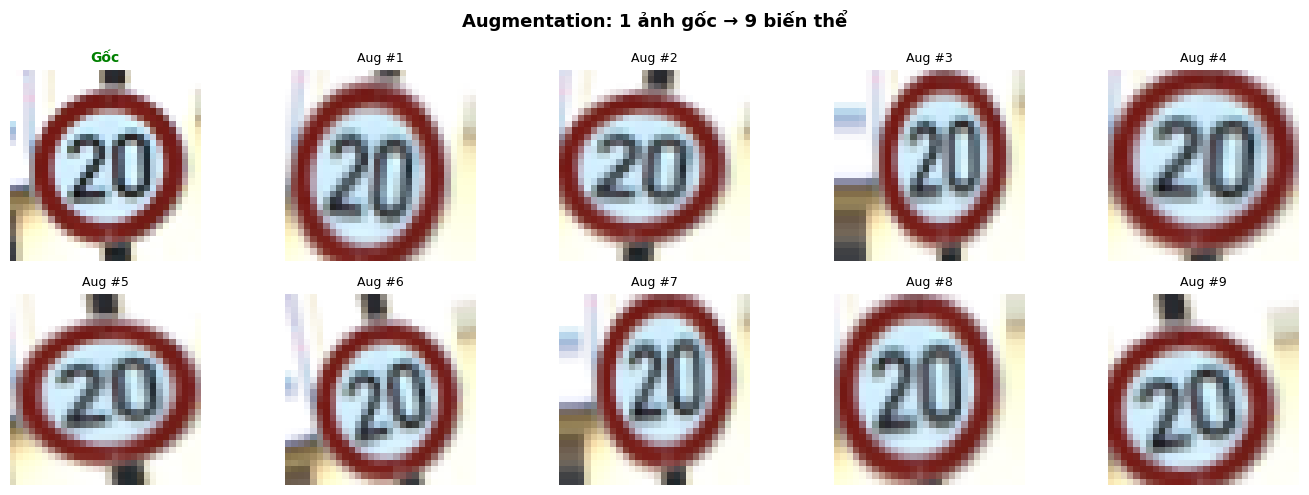

💾 Đã lưu: augmentation_samples.png


In [7]:
# Lấy 1 ảnh gốc và sinh ra 8 biến thể augmented
sample_img = X_train[0:1]
aug_iter = datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
fig.suptitle('Augmentation: 1 ảnh gốc → 9 biến thể', fontsize=13, fontweight='bold')

# Ảnh gốc
axes[0][0].imshow(sample_img[0])
axes[0][0].set_title('Gốc', fontsize=10, color='green', fontweight='bold')
axes[0][0].axis('off')

# 9 ảnh augmented
positions = [(0,1),(0,2),(0,3),(0,4),(1,0),(1,1),(1,2),(1,3),(1,4)]
for i, (r, c) in enumerate(positions):
    aug = next(aug_iter)[0]
    axes[r][c].imshow(np.clip(aug, 0, 1))
    axes[r][c].set_title(f'Aug #{i+1}', fontsize=9)
    axes[r][c].axis('off')

plt.tight_layout()
plt.savefig('augmentation_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: augmentation_samples.png")

## 🧠 Bước 4 — Xây dựng kiến trúc CNN

Kiến trúc gồm **2 khối Conv** và **1 khối Fully Connected**:

```
Input (30×30×3)
    │
    ├── Block 1: Conv2D(32) → BN → Conv2D(64) → MaxPool → Dropout(0.2)
    │
    ├── Block 2: Conv2D(128) → BN → Conv2D(256) → MaxPool → Dropout(0.3)
    │
    ├── Flatten
    ├── Dense(512, relu) → Dropout(0.4)
    └── Dense(43, softmax)  ← Output: xác suất 43 class
```

In [8]:
model = Sequential()

# ── Block 1 ──────────────────────────────────────────────
model.add(Conv2D(32, (5, 5), activation='relu', input_shape=X_train.shape[1:],
                 padding='valid', name='conv1_1'))
model.add(BatchNormalization(name='bn1'))
model.add(Conv2D(64, (5, 5), activation='relu', name='conv1_2'))
model.add(MaxPool2D(2, 2, name='pool1'))
model.add(Dropout(0.2, name='drop1'))

# ── Block 2 ──────────────────────────────────────────────
model.add(Conv2D(128, (3, 3), activation='relu', name='conv2_1'))
model.add(BatchNormalization(name='bn2'))
model.add(Conv2D(256, (3, 3), activation='relu', name='conv2_2'))
model.add(MaxPool2D(2, 2, name='pool2'))
model.add(Dropout(0.3, name='drop2'))

# ── Fully Connected ───────────────────────────────────────
model.add(Flatten(name='flatten'))
model.add(Dense(512, activation='relu', name='fc1'))
model.add(Dropout(0.4, name='drop3'))
model.add(Dense(classes, activation='softmax', name='output'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

c:\Users\Lactv\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 26, 26, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 26, 26, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 22, 22, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 9, 9, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,579 (6.20 MB)

 Trainable params: 1,625,259 (6.20 MB)

 Non-trainable params: 320 (1.25 KB)

### 📐 Visualize số lượng tham số từng layer

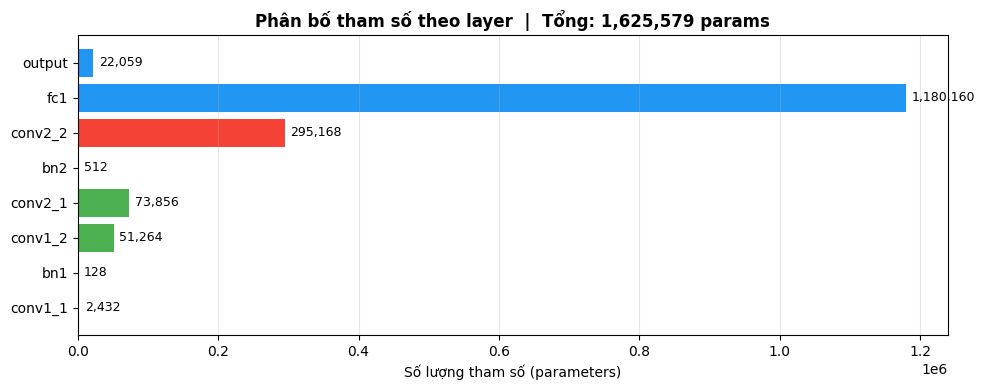

💾 Đã lưu: model_params.png

🔢 Tổng tham số: 1,625,579


In [9]:
layer_names = []
param_counts = []

for layer in model.layers:
    n_params = layer.count_params()
    if n_params > 0:
        layer_names.append(layer.name)
        param_counts.append(n_params)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2196F3', '#2196F3', '#4CAF50', '#4CAF50', '#FF9800', '#F44336']
bars = ax.barh(layer_names, param_counts,
               color=colors[:len(layer_names)], edgecolor='none')
ax.set_xlabel('Số lượng tham số (parameters)')
ax.set_title(f'Phân bố tham số theo layer  |  Tổng: {model.count_params():,} params',
             fontweight='bold')
ax.bar_label(bars, labels=[f'{v:,}' for v in param_counts], padding=4, fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('model_params.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Đã lưu: model_params.png")
print(f"\n🔢 Tổng tham số: {model.count_params():,}")

## 🏋️ Bước 5 — Huấn luyện mô hình

**Early Stopping**: Dừng sớm nếu `val_loss` không cải thiện sau **5 epoch** liên tiếp, đồng thời khôi phục weights tốt nhất.

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("🚀 Bắt đầu huấn luyện...")
print(f"   Batch size : 64")
print(f"   Max epochs : 50 (Early stopping patience=5)")
print("─" * 60)

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    epochs=50,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stop],
    verbose=1
)

print("─" * 60)
print("✅ Huấn luyện hoàn tất!")

🚀 Bắt đầu huấn luyện...
   Batch size : 64
   Max epochs : 50 (Early stopping patience=5)
────────────────────────────────────────────────────────────
Epoch 1/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 35s 66ms/step - accuracy: 0.5202 - loss: 1.6808 - val_accuracy: 0.9325 - val_loss: 0.3533
Epoch 2/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.8714 - loss: 0.4179 - val_accuracy: 0.9362 - val_loss: 0.2150
Epoch 3/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.9312 - loss: 0.2335 - val_accuracy: 0.9902 - val_loss: 0.0299
Epoch 4/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.9585 - loss: 0.1397 - val_accuracy: 0.9855 - val_loss: 0.0512
Epoch 5/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9619 - loss: 0.1299 - val_accuracy: 0.9881 - val_loss: 0.0491
Epoch 6/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.9694 - loss: 0.1117 - val_accuracy: 0.9857 - val_loss: 0.0532
Epoch 7/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9

### 📈 Visualize quá trình huấn luyện (Loss & Accuracy)

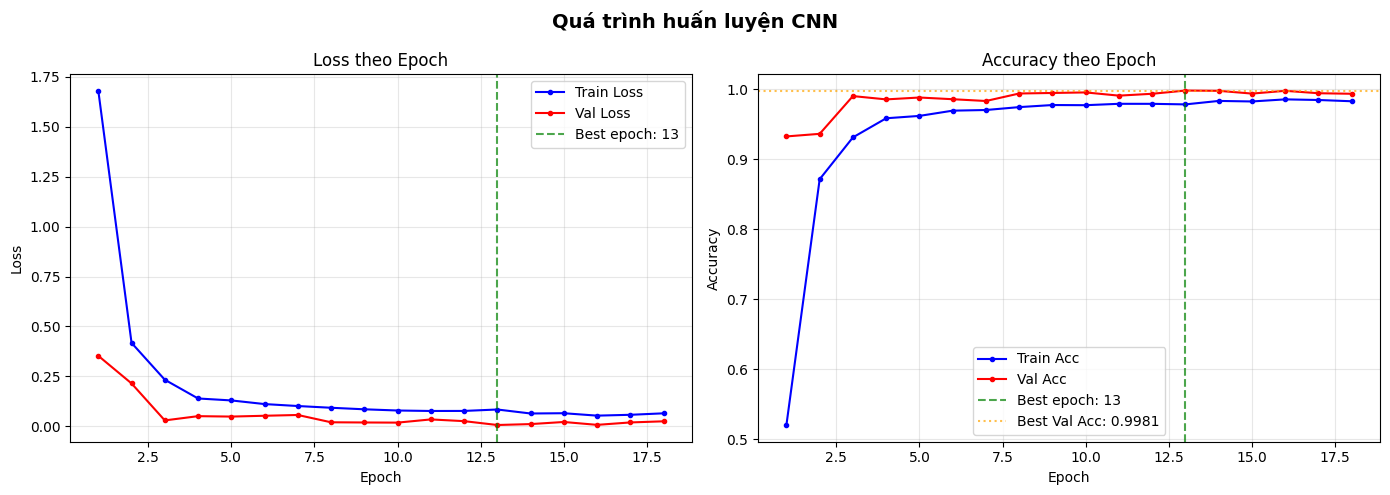

📌 Epoch tốt nhất : 13/18
📌 Val Accuracy   : 99.81%
📌 Val Loss       : 0.0069


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Quá trình huấn luyện CNN', fontsize=14, fontweight='bold')

epochs_ran = len(history.history['loss'])
x = range(1, epochs_ran + 1)

# Loss
ax1 = axes[0]
ax1.plot(x, history.history['loss'],     'b-o', markersize=3, label='Train Loss')
ax1.plot(x, history.history['val_loss'], 'r-o', markersize=3, label='Val Loss')
best_epoch = np.argmin(history.history['val_loss']) + 1
ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
            label=f'Best epoch: {best_epoch}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss theo Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2 = axes[1]
ax2.plot(x, history.history['accuracy'],     'b-o', markersize=3, label='Train Acc')
ax2.plot(x, history.history['val_accuracy'], 'r-o', markersize=3, label='Val Acc')
ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
            label=f'Best epoch: {best_epoch}')
best_acc = max(history.history['val_accuracy'])
ax2.axhline(y=best_acc, color='orange', linestyle=':', alpha=0.7,
            label=f'Best Val Acc: {best_acc:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy theo Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📌 Epoch tốt nhất : {best_epoch}/{epochs_ran}")
print(f"📌 Val Accuracy   : {best_acc*100:.2f}%")
print(f"📌 Val Loss       : {min(history.history['val_loss']):.4f}")

## 💾 Bước 6 — Lưu model và labels

In [12]:
# Lưu model
model.save("traffic_classifier.h5")
print("✅ Đã lưu model: traffic_classifier.h5")

# Lưu label map
label_map = {
    0: "Giới hạn tốc độ 20 km/h",    1: "Giới hạn tốc độ 30 km/h",
    2: "Giới hạn tốc độ 50 km/h",    3: "Giới hạn tốc độ 60 km/h",
    4: "Giới hạn tốc độ 70 km/h",    5: "Giới hạn tốc độ 80 km/h",
    6: "Hết giới hạn tốc độ 80 km/h",7: "Giới hạn tốc độ 100 km/h",
    8: "Giới hạn tốc độ 120 km/h",   9: "Cấm vượt",
    10: "Cấm vượt xe trên 3.5 tấn",  11: "Ưu tiên tại giao lộ",
    12: "Đường ưu tiên",              13: "Nhường đường",
    14: "Dừng lại",                   15: "Cấm tất cả phương tiện",
    16: "Cấm xe trên 3.5 tấn",       17: "Cấm vào",
    18: "Nguy hiểm chung",            19: "Nguy hiểm: cua trái",
    20: "Nguy hiểm: cua phải",        21: "Nguy hiểm: đường cong liên tiếp",
    22: "Đường gồ ghề",              23: "Đường trơn trượt",
    24: "Đường hẹp bên phải",         25: "Công trường",
    26: "Đèn giao thông",             27: "Người đi bộ",
    28: "Trẻ em qua đường",           29: "Xe đạp qua đường",
    30: "Cảnh báo băng/tuyết",        31: "Động vật hoang dã",
    32: "Hết mọi giới hạn tốc độ và cấm vượt",
    33: "Rẽ phải phía trước",         34: "Rẽ trái phía trước",
    35: "Chỉ được đi thẳng",          36: "Đi thẳng hoặc rẽ phải",
    37: "Đi thẳng hoặc rẽ trái",      38: "Đi bên phải",
    39: "Đi bên trái",                40: "Vòng xuyến",
    41: "Hết cấm vượt",               42: "Hết cấm vượt xe trên 3.5 tấn"
}

with open("labels.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)
print("✅ Đã lưu labels: labels.json")
print(f"   Kích thước model: {os.path.getsize('traffic_classifier.h5') / 1024 / 1024:.1f} MB")

✅ Đã lưu model: traffic_classifier.h5
✅ Đã lưu labels: labels.json
   Kích thước model: 18.7 MB


## 📊 Bước 7 — Đánh giá trên Test.csv + Confusion Matrix

In [13]:
try:
    test_csv = pd.read_csv('Test.csv')
    labels_test = test_csv["ClassId"].values
    imgs_test   = test_csv["Path"].values

    data_test = []
    for img_path in imgs_test:
        img = Image.open(img_path).convert("RGB").resize((30, 30))
        data_test.append(np.array(img) / 255.0)

    X_test_final = np.array(data_test)
    pred = np.argmax(model.predict(X_test_final, verbose=0), axis=-1)

    acc = accuracy_score(labels_test, pred)
    print(f"🎯 Accuracy trên Test.csv: {acc*100:.2f}%")
    print("\n" + classification_report(labels_test, pred,
          target_names=[label_names.get(i, str(i)) for i in range(43)]))

except FileNotFoundError:
    print("⚠️  Không tìm thấy Test.csv — bỏ qua bước đánh giá CSV.")
    print("   Đặt file Test.csv vào cùng thư mục và chạy lại cell này.")

🎯 Accuracy trên Test.csv: 97.85%

                precision    recall  f1-score   support

     Tốc độ 20       0.95      1.00      0.98        60
     Tốc độ 30       0.97      1.00      0.99       720
     Tốc độ 50       0.98      1.00      0.99       750
     Tốc độ 60       1.00      0.96      0.98       450
     Tốc độ 70       1.00      0.97      0.98       660
     Tốc độ 80       0.96      0.98      0.97       630
        Hết 80       1.00      1.00      1.00       150
    Tốc độ 100       0.98      1.00      0.99       450
    Tốc độ 120       1.00      0.99      0.99       450
      Cấm vượt       1.00      1.00      1.00       480
Cấm vượt >3.5T       1.00      1.00      1.00       660
Ưu tiên ngã tư       0.95      0.95      0.95       420
 Đường ưu tiên       1.00      0.98      0.99       690
  Nhường đường       1.00      1.00      1.00       720
          STOP       1.00      1.00      1.00       270
        Cấm xe       0.96      1.00      0.98       210
  Cấm xe >3.5

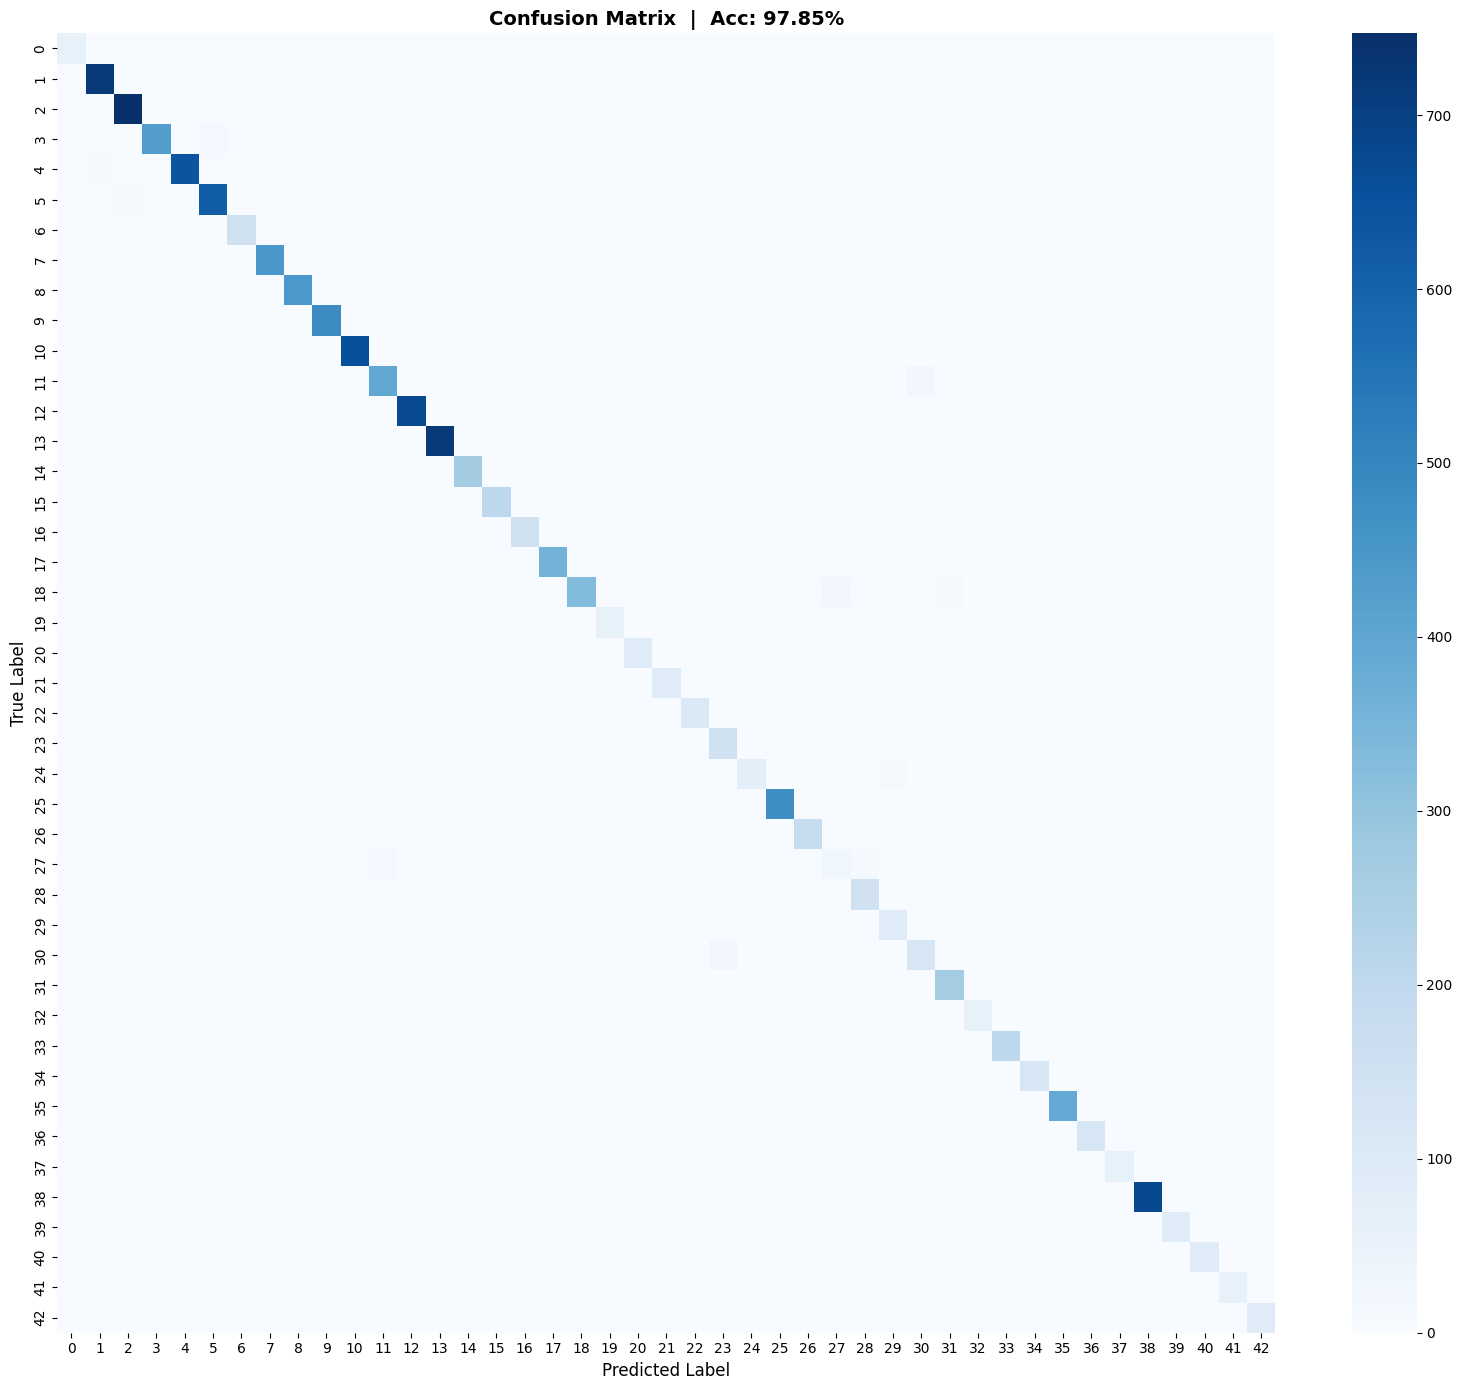

💾 Đã lưu: confusion_matrix.png


In [14]:
# Confusion Matrix — chạy sau cell trên nếu có Test.csv
try:
    cm = confusion_matrix(labels_test, pred)

    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=range(43), yticklabels=range(43), ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f'Confusion Matrix  |  Acc: {acc*100:.2f}%', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("💾 Đã lưu: confusion_matrix.png")
except NameError:
    print("⚠️  Chạy cell trên trước để có dữ liệu Test.csv")

## ✅ Tóm tắt kết quả

| File đầu ra | Mô tả |
|---|---|
| `traffic_classifier.h5` | Model CNN đã huấn luyện |
| `labels.json` | Bản đồ class ID → tên biển báo |
| `data_distribution.png` | Phân phối số ảnh theo class |
| `sample_images.png` | Mẫu ảnh 43 class |
| `augmentation_samples.png` | Minh họa Data Augmentation |
| `training_history.png` | Loss & Accuracy theo epoch |
| `model_params.png` | Phân bố tham số theo layer |
| `confusion_matrix.png` | Ma trận nhầm lẫn trên Test.csv |

**Bước tiếp theo:** Mở notebook `02_Camera.ipynb` để tìm hiểu nhận diện realtime qua webcam.